<a href="https://colab.research.google.com/github/sujeengim/ML-algorithm/blob/main/Linear_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#실습용 데이터셋
## load_iris(classification)
## load_diabetes(regression)
## load_digits (classification)
## load_linnerud (physical exercise linnerud dataset)
## load_wine (classification)
## load_breast_cancer(classification)

from sklearn.datasets import load_iris
iris = load_iris()




In [2]:
iris.keys() #데이터셋 내부 구조 확인

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
print(iris.DESCR) #데이터 설명

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

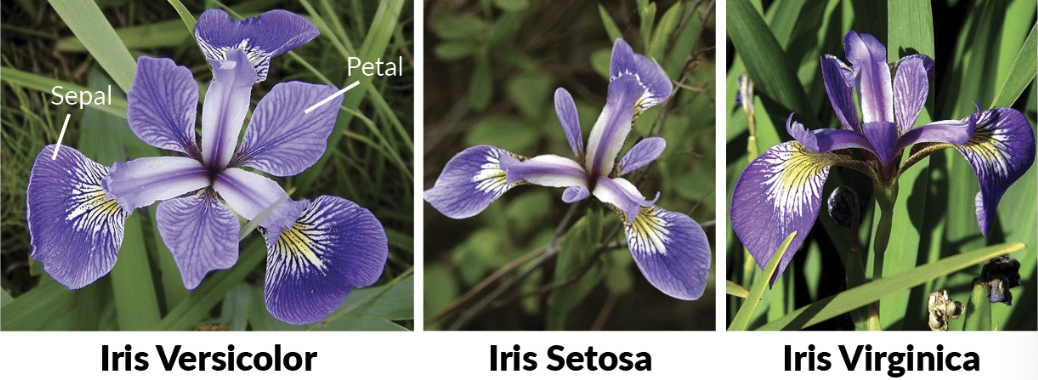

In [5]:
iris.feature_names #입력변수 이름

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris.data[:5] #입력변수 값

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [8]:
iris.target_names #출력변수 클래스 이름

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

setosa => 0

versicolor => 1

virginica => 2



In [9]:
iris.target #출력변수 정답(label)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

가장 첫번째 입력변수 값(data[0]==[5.1, 3.5, 1.4, 0.2])의 정답(target)은 target을 출력해봤을때 가장 처음 뜨는 값(0)이다.


이 data[0]의 순서는 feature_names를 출력했을 때 나오는 순서다.

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

## 1. pandas로 데이터 탐색 해보자.


In [12]:
import pandas as pd

In [13]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
df.describe() #연속형 변수의 전체적 분포 파악

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [15]:
df["species"] = iris.target #label 변수 추가
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


array([[<Axes: xlabel='sepal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal width (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal width (cm)'>,
  

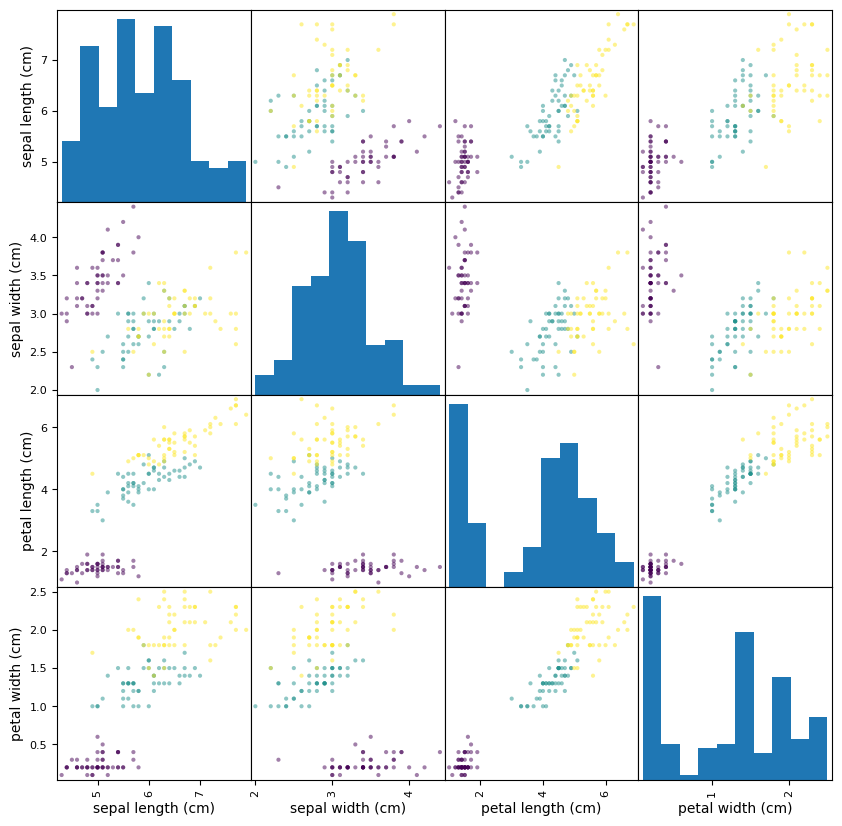

In [16]:
# 연속형 변수간 관계 산점도 표현
pd.plotting.scatter_matrix(df.iloc[:,:-1], figsize=(10,10), c=df.species)

## 2. Scikit-Learn 기반 데이터 전처리 및 모델 학습/평가

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()# 라벨 클래스 이름을 o~k-1의 숫자로 변환
le.fit(iris.target_names)

le.classes_ #classes_ : 각 클래스 이름 정보 저장

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [20]:
le.transform(['setosa', 'virginica'])

array([0, 2])

In [21]:
le.inverse_transform([1,2,0])

array(['versicolor', 'virginica', 'setosa'], dtype='<U10')

In [22]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [23]:
le.inverse_transform(iris.target)

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

이제 모델 정의 해보자
### linear_model.LogisticRegression
- multi_class : {'auto', 'ovr', 'multinomial'}
- max_iter : 최대 반복 횟수(기본값:100)
- penalty : {'l1', 'l2', 'elasticnet', None}

### 모델 학습
fit(X, y)

In [24]:
from sklearn.linear_model import LogisticRegression

softmax_reg = LogisticRegression(multi_class="multinomial", max_iter=5000)
softmax_reg.fit(iris.data, iris.target)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='multinomial')

### 예측

In [26]:
# 클래스별 예측 확룰
y_prob = softmax_reg.predict_proba(iris.data)
y_prob[:10]

array([[9.81557202e-01, 1.84427831e-02, 1.44809203e-08],
       [9.71331260e-01, 2.86687094e-02, 3.01371913e-08],
       [9.85267666e-01, 1.47323220e-02, 1.23160869e-08],
       [9.76066960e-01, 2.39330004e-02, 3.96147889e-08],
       [9.85211691e-01, 1.47882972e-02, 1.19885635e-08],
       [9.70143790e-01, 2.98561356e-02, 7.39603616e-08],
       [9.86761673e-01, 1.32383072e-02, 1.99502967e-08],
       [9.76125288e-01, 2.38746840e-02, 2.76894517e-08],
       [9.79639479e-01, 2.03604905e-02, 3.05286472e-08],
       [9.68765887e-01, 3.12340817e-02, 3.16602580e-08]])

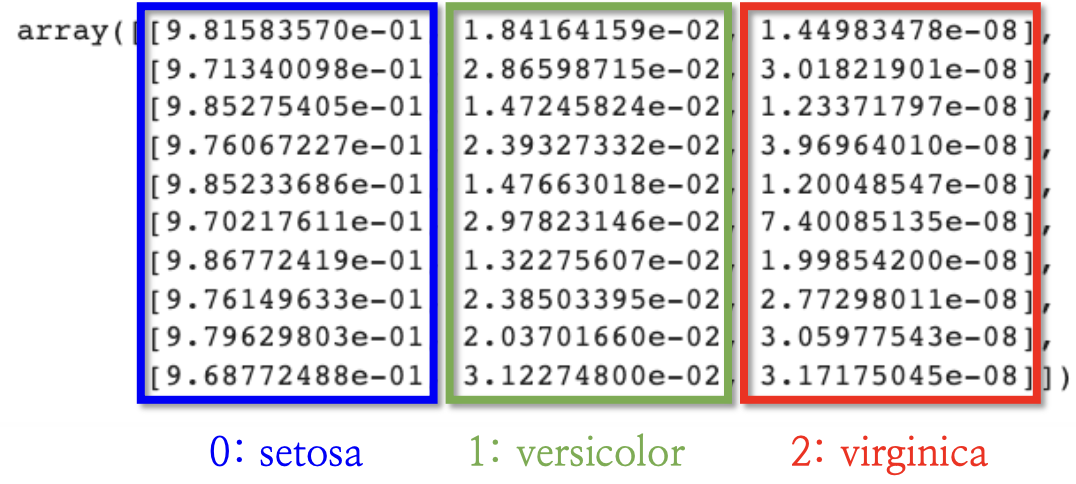

In [28]:
# 클래스별 예측
y_cls = softmax_reg.predict(iris.data)
y_cls[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### 정확도

In [30]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(iris.target, y_cls))

Accuracy: 0.9733333333333334


In [32]:
#학습 통해 추정된 모델 파라미터
print("Coefficients:", softmax_reg.coef_)
print("Intercept:", softmax_reg.intercept_)

Coefficients: [[-0.42415938  0.96633485 -2.5160372  -1.08205245]
 [ 0.53464109 -0.32039706 -0.20702001 -0.94324899]
 [-0.11048172 -0.64593779  2.72305721  2.02530144]]
Intercept: [  9.85533212   2.23415948 -12.0894916 ]
